In [1]:
# ============================================================
# CELL 1 — INSTALL (Optional)
# ============================================================

# Uncomment if dependencies are missing
# !pip install sentence-transformers faiss-cpu rank-bm25 groq python-dotenv

In [2]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import faiss
import pickle
import json
import os
import time
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
from groq import Groq
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

load_dotenv()

print("Libraries loaded successfully.")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries loaded successfully.
Timestamp: 2026-05-26 16:26:38


In [3]:
# ============================================================
# CELL 3 — CONFIGURATION
# ============================================================

CONFIG = {
    # Paths
    "faiss_index_path": "../parquet_exports/ticket_similarity.index",
    "embedding_metadata_path": "../parquet_exports/embedding_metadata.parquet",
    "bm25_corpus_path": "../parquet_exports/bm25_corpus.pkl",
    "results_export_path": "../evaluation/rag_pipeline_results.csv",
    "sample_export_path": "../evaluation/sample_rag_response.txt",
    "benchmark_export_path": "../evaluation/benchmarks/rag_latency.csv",

    # Models
    "embedding_model_name": "sentence-transformers/all-MiniLM-L6-v2",
    "cross_encoder_model_name": "cross-encoder/ms-marco-MiniLM-L-6-v2",
    "llm_model_name": "llama-3.3-70b-versatile",

    # Retrieval params
    "top_k_faiss": 20,
    "top_k_bm25": 20,
    "rrf_k": 60,
    "hybrid_top_k": 10,

    # Reranking params
    "rerank_top_k": 5,
    "cross_encoder_batch_size": 32,

    # Generation params
    "llm_temperature": 0.1,
    "llm_max_tokens": 1024,
    "max_context_tokens": 4096,
    "context_doc_separator": "\n---\n",

    # API
    "groq_api_key_env": "GROQ_API_KEY",
    "groq_request_timeout": 30,
}

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

CONFIGURATION
  faiss_index_path: ../parquet_exports/ticket_similarity.index
  embedding_metadata_path: ../parquet_exports/embedding_metadata.parquet
  bm25_corpus_path: ../parquet_exports/bm25_corpus.pkl
  results_export_path: ../evaluation/rag_pipeline_results.csv
  sample_export_path: ../evaluation/sample_rag_response.txt
  benchmark_export_path: ../evaluation/benchmarks/rag_latency.csv
  embedding_model_name: sentence-transformers/all-MiniLM-L6-v2
  cross_encoder_model_name: cross-encoder/ms-marco-MiniLM-L-6-v2
  llm_model_name: llama-3.3-70b-versatile
  top_k_faiss: 20
  top_k_bm25: 20
  rrf_k: 60
  hybrid_top_k: 10
  rerank_top_k: 5
  cross_encoder_batch_size: 32
  llm_temperature: 0.1
  llm_max_tokens: 1024
  max_context_tokens: 4096
  context_doc_separator: 
---

  groq_api_key_env: GROQ_API_KEY
  groq_request_timeout: 30


In [4]:
# ============================================================
# CELL 4 — LOGGING HELPERS
# ============================================================

def log(level, component, message):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] [{level}] [{component}] {message}")


def log_step(step_name):
    print(f"\n{'=' * 60}")
    print(f"  {step_name}")
    print(f"{'=' * 60}")


print("Logging helpers ready.")

Logging helpers ready.


In [5]:
# ============================================================
# CELL 5 — LOAD FAISS INDEX
# ============================================================

index = None
try:
    log_step("LOADING FAISS INDEX")
    t0 = time.time()
    index = faiss.read_index(CONFIG["faiss_index_path"])
    elapsed = time.time() - t0
    log("OK", "FAISS", f"Loaded {index.ntotal:,} vectors in {elapsed:.2f}s")
    assert index.ntotal > 0, "FAISS index is empty"
    log("OK", "FAISS", f"Dimension: {index.d}")
except FileNotFoundError:
    log("ERROR", "FAISS", f"Index not found at {CONFIG['faiss_index_path']}")
    log("ERROR", "FAISS", "Run notebook 06_embedding_pipeline.ipynb first")
    raise
except Exception as e:
    log("ERROR", "FAISS", f"Failed to load: {e}")
    raise


  LOADING FAISS INDEX


[16:26:38] [OK] [FAISS] Loaded 230,088 vectors in 0.35s
[16:26:38] [OK] [FAISS] Dimension: 384


In [6]:
# ============================================================
# CELL 6 — LOAD METADATA
# ============================================================

metadata_df = None
required_cols = ["chunk_id", "chunk_text", "document_id", "ticket_pk"]

try:
    log_step("LOADING METADATA")
    t0 = time.time()
    metadata_df = pd.read_parquet(CONFIG["embedding_metadata_path"])
    elapsed = time.time() - t0
    log("OK", "METADATA", f"Loaded {len(metadata_df):,} rows, {metadata_df.shape[1]} cols in {elapsed:.2f}s")

    missing_cols = [c for c in required_cols if c not in metadata_df.columns]
    if missing_cols:
        log("WARN", "METADATA", f"Missing columns: {missing_cols}")
    else:
        log("OK", "METADATA", f"Required columns present: {required_cols}")
except FileNotFoundError:
    log("ERROR", "METADATA", f"File not found at {CONFIG['embedding_metadata_path']}")
    raise
except Exception as e:
    log("ERROR", "METADATA", f"Failed to load: {e}")
    raise


  LOADING METADATA


[16:26:38] [OK] [METADATA] Loaded 230,088 rows, 9 cols in 0.21s
[16:26:38] [OK] [METADATA] Required columns present: ['chunk_id', 'chunk_text', 'document_id', 'ticket_pk']


In [7]:
# ============================================================
# CELL 7 — LOAD BM25 CORPUS & BUILD INDEX
# ============================================================

bm25 = None
bm25_tokens = None

try:
    log_step("LOADING BM25 CORPUS")
    t0 = time.time()
    bm25_tokens = pd.read_pickle(CONFIG["bm25_corpus_path"])
    log("OK", "BM25", f"Loaded {len(bm25_tokens):,} documents in {time.time()-t0:.2f}s")

    assert len(bm25_tokens) > 0, "BM25 corpus is empty"

    t0 = time.time()
    bm25 = BM25Okapi(bm25_tokens.tolist())
    log("OK", "BM25", f"Index built in {time.time()-t0:.2f}s")
except FileNotFoundError:
    log("ERROR", "BM25", f"File not found at {CONFIG['bm25_corpus_path']}")
    raise
except Exception as e:
    log("ERROR", "BM25", f"Failed to load: {e}")
    raise


  LOADING BM25 CORPUS


[16:26:40] [OK] [BM25] Loaded 230,088 documents in 1.23s


[16:26:43] [OK] [BM25] Index built in 3.48s


In [8]:
# ============================================================
# CELL 8 — LOAD EMBEDDING MODEL
# ============================================================

embedding_model = None

try:
    log_step("LOADING EMBEDDING MODEL")
    t0 = time.time()
    embedding_model = SentenceTransformer(CONFIG["embedding_model_name"])
    elapsed = time.time() - t0
    log("OK", "EMBEDDING", f"Model '{CONFIG['embedding_model_name']}' loaded in {elapsed:.2f}s")
    log("OK", "EMBEDDING", f"Device: {embedding_model.device}")
except Exception as e:
    log("ERROR", "EMBEDDING", f"Failed to load model: {e}")
    raise


  LOADING EMBEDDING MODEL


[16:26:46] [OK] [EMBEDDING] Model 'sentence-transformers/all-MiniLM-L6-v2' loaded in 3.22s
[16:26:46] [OK] [EMBEDDING] Device: cpu


In [9]:
# ============================================================
# CELL 9 — RETRIEVAL FUNCTIONS
# ============================================================

def faiss_search(query: str, top_k: int = 10) -> pd.DataFrame:
    try:
        q_emb = embedding_model.encode(
            [query], convert_to_numpy=True, normalize_embeddings=True
        ).astype("float32")
        scores, indices = index.search(q_emb, top_k)
        results = []
        for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
            row = metadata_df.iloc[idx]
            results.append({
                "retriever": "faiss",
                "rank": rank + 1,
                "score": float(score),
                "chunk_id": row["chunk_id"],
                "text": row["chunk_text"]
            })
        return pd.DataFrame(results)
    except Exception as e:
        log("ERROR", "FAISS_SEARCH", f"Query failed: {e}")
        return pd.DataFrame(columns=["retriever", "rank", "score", "chunk_id", "text"])


def bm25_search(query: str, top_k: int = 10) -> pd.DataFrame:
    try:
        tok_q = query.lower().split()
        scores = bm25.get_scores(tok_q)
        top_indices = np.argsort(scores)[::-1][:top_k]
        results = []
        for rank, idx in enumerate(top_indices):
            row = metadata_df.iloc[idx]
            results.append({
                "retriever": "bm25",
                "rank": rank + 1,
                "score": float(scores[idx]),
                "chunk_id": row["chunk_id"],
                "text": row["chunk_text"]
            })
        return pd.DataFrame(results)
    except Exception as e:
        log("ERROR", "BM25_SEARCH", f"Query failed: {e}")
        return pd.DataFrame(columns=["retriever", "rank", "score", "chunk_id", "text"])


def reciprocal_rank_fusion(result_frames: list, k: int = 60) -> pd.DataFrame:
    rrf_scores = {}
    text_lookup = {}
    for df in result_frames:
        for _, row in df.iterrows():
            cid = row["chunk_id"]
            rrf_scores[cid] = rrf_scores.get(cid, 0) + 1 / (k + row["rank"])
            text_lookup[cid] = row["text"]
    fused = pd.DataFrame([
        {"chunk_id": cid, "rrf_score": sc, "text": text_lookup[cid]}
        for cid, sc in rrf_scores.items()
    ])
    return fused.sort_values("rrf_score", ascending=False).reset_index(drop=True)


def hybrid_search(query: str, top_k: int = 10) -> pd.DataFrame:
    bm25_df = bm25_search(query, top_k=top_k)
    faiss_df = faiss_search(query, top_k=top_k)
    if bm25_df.empty and faiss_df.empty:
        log("WARN", "HYBRID", f"Both retrievers returned empty for: {query}")
        return pd.DataFrame(columns=["chunk_id", "rrf_score", "text"])
    return reciprocal_rank_fusion([bm25_df, faiss_df], k=CONFIG["rrf_k"]).head(top_k)


print("Retrieval functions defined.")

Retrieval functions defined.


In [10]:
# ============================================================
# CELL 10 — LOAD CROSS-ENCODER
# ============================================================

cross_encoder = None

try:
    log_step("LOADING CROSS-ENCODER")
    t0 = time.time()
    cross_encoder = CrossEncoder(
        CONFIG["cross_encoder_model_name"],
        max_length=CONFIG["max_context_tokens"],
    )
    elapsed = time.time() - t0
    log("OK", "CROSSENCODER", f"Model '{CONFIG['cross_encoder_model_name']}' loaded in {elapsed:.2f}s")
except Exception as e:
    log("ERROR", "CROSSENCODER", f"Failed to load: {e}")
    log("WARN", "CROSSENCODER", "Continuing without reranking")
    cross_encoder = None


  LOADING CROSS-ENCODER


[16:26:48] [OK] [CROSSENCODER] Model 'cross-encoder/ms-marco-MiniLM-L-6-v2' loaded in 1.56s


In [11]:
# ============================================================
# CELL 11 — RERANKING FUNCTIONS
# ============================================================

def rerank_results(
    query: str,
    hybrid_df: pd.DataFrame,
    top_k: int = 5,
) -> pd.DataFrame:
    if cross_encoder is None:
        log("WARN", "RERANK", "No CrossEncoder available, returning hybrid results")
        hybrid_df["rerank_score"] = hybrid_df["rrf_score"]
        return hybrid_df.head(top_k)

    if hybrid_df.empty:
        log("WARN", "RERANK", "Empty input, returning empty")
        return hybrid_df

    try:
        pairs = [[query, text] for text in hybrid_df["text"].tolist()]
        rerank_scores = cross_encoder.predict(
            pairs,
            batch_size=CONFIG["cross_encoder_batch_size"],
            show_progress_bar=False,
        )
        rerank_scores = rerank_scores.tolist() if hasattr(rerank_scores, "tolist") else list(rerank_scores)

        result_df = hybrid_df.copy()
        result_df["rerank_score"] = rerank_scores
        result_df = result_df.sort_values("rerank_score", ascending=False).reset_index(drop=True)
        result_df["rerank_rank"] = range(1, len(result_df) + 1)

        log("OK", "RERANK", f"Reranked {len(result_df)} items, top score: {result_df['rerank_score'].iloc[0]:.4f}")
        return result_df.head(top_k)
    except Exception as e:
        log("ERROR", "RERANK", f"Reranking failed: {e}")
        hybrid_df["rerank_score"] = hybrid_df["rrf_score"]
        return hybrid_df.head(top_k)


print("Reranking functions defined.")

Reranking functions defined.


In [12]:
# ============================================================
# CELL 12 — GROQ CLIENT INITIALIZATION
# ============================================================

groq_client = None

try:
    log_step("INITIALIZING GROQ CLIENT")
    api_key = os.getenv(CONFIG["groq_api_key_env"])
    if not api_key or api_key.strip() == "":
        raise ValueError(f"Environment variable {CONFIG['groq_api_key_env']} is not set or empty")
    api_key = api_key.strip().strip('"').strip("'")
    groq_client = Groq(api_key=api_key)
    log("OK", "GROQ", f"Client initialized with model: {CONFIG['llm_model_name']}")
except Exception as e:
    log("ERROR", "GROQ", f"Failed to initialize Groq client: {e}")
    log("WARN", "GROQ", "RAG generation will be skipped. Ensure GROQ_API_KEY is set in .env")
    groq_client = None


  INITIALIZING GROQ CLIENT


[16:26:48] [OK] [GROQ] Client initialized with model: llama-3.3-70b-versatile


In [13]:
# ============================================================
# CELL 13 — CONTEXT BUILDER & PROMPT TEMPLATE
# ============================================================

def estimate_tokens(text: str) -> int:
    return len(text.split())


def build_context(results_df: pd.DataFrame) -> dict:
    if results_df.empty:
        return {"context_text": "", "num_chunks": 0, "total_tokens": 0,
                "chunk_ids": [], "warnings": ["No results to build context from"]}

    texts = results_df["text"].tolist()
    chunk_ids = results_df["chunk_id"].tolist()

    tokens_per_chunk = [estimate_tokens(t) for t in texts]
    total_tokens = sum(tokens_per_chunk)

    warnings = []

    duplicates = results_df["chunk_id"].duplicated().sum()
    if duplicates > 0:
        warnings.append(f"{duplicates} duplicate chunk_ids in context")

    empty_chunks = sum(1 for t in texts if not t.strip())
    if empty_chunks > 0:
        warnings.append(f"{empty_chunks} empty text chunks in context")

    if total_tokens > CONFIG["max_context_tokens"]:
        warnings.append(f"Context ({total_tokens} tokens) exceeds limit ({CONFIG['max_context_tokens']})")

    sep = CONFIG["context_doc_separator"]
    context_parts = []
    for i, (cid, text) in enumerate(zip(chunk_ids, texts), 1):
        context_parts.append(f"[Document {i}] (ID: {cid})\n{text}")

    context_text = sep.join(context_parts)

    return {
        "context_text": context_text,
        "num_chunks": len(texts),
        "total_tokens": total_tokens,
        "tokens_per_chunk": tokens_per_chunk,
        "chunk_ids": chunk_ids,
        "warnings": warnings,
    }


SYSTEM_PROMPT = (
    "You are an AI assistant for an IT Service Desk. "
    "Your role is to help IT support agents resolve tickets quickly and accurately. "
    "Answer the user's question based ONLY on the provided context documents. "
    "If the context does not contain enough information, say so clearly. "
    "Be specific, concise, and actionable. "
    "Include relevant troubleshooting steps, root causes, or solutions when available."
)


def build_prompt(query: str, context_info: dict) -> str:
    if not context_info["context_text"].strip():
        return f"{SYSTEM_PROMPT}\n\nNo relevant context was found for this query. " \
               f"Answer based on your general knowledge, but clearly state when information is not from the knowledge base.\n\n" \
               f"User Question: {query}"

    prompt = (
        f"{SYSTEM_PROMPT}\n\n"
        f"## Context Documents\n"
        f"{context_info['context_text']}\n\n"
        f"## User Question\n"
        f"{query}\n\n"
        f"## Instructions\n"
        f"Based on the context documents above, provide a helpful and accurate response. "
        f"If the context is insufficient, acknowledge the limitation."
    )
    return prompt


print("Context builder and prompt template defined.")

Context builder and prompt template defined.


In [14]:
# ============================================================
# CELL 14 — GENERATION FUNCTIONS
# ============================================================

def generate_rag_response(query: str, context_info: dict) -> dict:
    if groq_client is None:
        return {
            "response": "[Groq client not initialized. Set GROQ_API_KEY in .env]",
            "error": "Groq client not available",
            "latency_ms": 0,
            "prompt_tokens": 0,
            "completion_tokens": 0,
        }

    try:
        prompt = build_prompt(query, context_info)
        prompt_tokens = estimate_tokens(prompt)

        t0 = time.time()
        completion = groq_client.chat.completions.create(
            model=CONFIG["llm_model_name"],
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": prompt},
            ],
            temperature=CONFIG["llm_temperature"],
            max_tokens=CONFIG["llm_max_tokens"],
        )
        latency_ms = (time.time() - t0) * 1000

        response_text = completion.choices[0].message.content
        usage = completion.usage
        completion_tokens = usage.completion_tokens if usage else 0

        log("OK", "GENERATION", f"Response generated in {latency_ms:.0f}ms "
            f"(prompt={prompt_tokens}, completion={completion_tokens} tokens)")

        return {
            "response": response_text,
            "error": None,
            "latency_ms": round(latency_ms, 1),
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens": prompt_tokens + completion_tokens,
        }
    except Exception as e:
        log("ERROR", "GENERATION", f"Groq API call failed: {e}")
        return {
            "response": f"[Generation failed: {e}]",
            "error": str(e),
            "latency_ms": 0,
            "prompt_tokens": 0,
            "completion_tokens": 0,
        }


def retrieve_rerank_generate(query: str) -> dict:
    t_start = time.time()

    # Stage 1: Hybrid Retrieval
    t0 = time.time()
    hybrid_df = hybrid_search(query, top_k=CONFIG["hybrid_top_k"])
    retrieval_ms = (time.time() - t0) * 1000

    if hybrid_df.empty:
        log("WARN", "PIPELINE", f"Retrieval returned no results for: {query}")
        return {
            "query": query,
            "retrieval_ms": round(retrieval_ms, 1),
            "rerank_ms": 0,
            "generation_ms": 0,
            "total_ms": round((time.time() - t_start) * 1000, 1),
            "num_chunks": 0,
            "response": "[No relevant documents found in the knowledge base]",
            "error": "empty_retrieval",
            "context_tokens": 0,
            "completion_tokens": 0,
        }

    # Stage 2: Reranking
    t0 = time.time()
    reranked_df = rerank_results(query, hybrid_df, top_k=CONFIG["rerank_top_k"])
    rerank_ms = (time.time() - t0) * 1000

    # Stage 3: Build Context
    context_info = build_context(reranked_df)

    if context_info["warnings"]:
        for w in context_info["warnings"]:
            log("WARN", "CONTEXT", w)

    # Stage 4: Generate
    t0 = time.time()
    gen_result = generate_rag_response(query, context_info)
    generation_ms = (time.time() - t0) * 1000

    total_ms = (time.time() - t_start) * 1000

    log("OK", "PIPELINE", f"Query: '{query}' | "
        f"Retrieval: {retrieval_ms:.0f}ms | "
        f"Rerank: {rerank_ms:.0f}ms | "
        f"Generate: {generation_ms:.0f}ms | "
        f"Total: {total_ms:.0f}ms | "
        f"Chunks: {context_info['num_chunks']} → {context_info['total_tokens']} tokens")

    return {
        "query": query,
        "retrieval_ms": round(retrieval_ms, 1),
        "rerank_ms": round(rerank_ms, 1),
        "generation_ms": round(generation_ms, 1),
        "total_ms": round(total_ms, 1),
        "num_chunks": context_info["num_chunks"],
        "context_tokens": context_info["total_tokens"],
        "chunk_ids": context_info["chunk_ids"],
        "response": gen_result["response"],
        "completion_tokens": gen_result["completion_tokens"],
        "prompt_tokens": gen_result["prompt_tokens"],
        "error": gen_result["error"],
    }


print("Generation pipeline functions defined.")

Generation pipeline functions defined.


In [15]:
# ============================================================
# CELL 15 — SINGLE QUERY TEST
# ============================================================

log_step("SINGLE QUERY: FULL RAG PIPELINE")

test_query = "VPN timeout after windows update"

log("INFO", "TEST", f"Query: '{test_query}'")

result = retrieve_rerank_generate(test_query)

print(f"\n{'=' * 60}")
print("RETRIEVED CONTEXT")
print(f"{'=' * 60}")
print(f"Chunks retrieved: {result['num_chunks']}")
print(f"Context tokens: {result['context_tokens']}")
print(f"Chunk IDs: {result['chunk_ids']}")

print(f"\n{'=' * 60}")
print("GENERATED RESPONSE")
print(f"{'=' * 60}")
print(result["response"][:1000] if result["response"] else "[Empty response]")

print(f"\n{'=' * 60}")
print("LATENCY BREAKDOWN")
print(f"{'=' * 60}")
print(f"  Retrieval:  {result['retrieval_ms']:.0f} ms")
print(f"  Rerank:     {result['rerank_ms']:.0f} ms")
print(f"  Generation: {result['generation_ms']:.0f} ms")
print(f"  Total:      {result['total_ms']:.0f} ms")
print(f"  Completion tokens: {result['completion_tokens']}")


  SINGLE QUERY: FULL RAG PIPELINE
[16:26:48] [INFO] [TEST] Query: 'VPN timeout after windows update'


[16:26:49] [OK] [RERANK] Reranked 10 items, top score: -5.6852


[16:26:51] [OK] [GENERATION] Response generated in 1225ms (prompt=364, completion=158 tokens)
[16:26:51] [OK] [PIPELINE] Query: 'VPN timeout after windows update' | Retrieval: 514ms | Rerank: 485ms | Generate: 1225ms | Total: 2226ms | Chunks: 5 → 247 tokens

RETRIEVED CONTEXT
Chunks retrieved: 5
Context tokens: 247
Chunk IDs: ['doc_205775_chunk_0', 'doc_225270_chunk_0', 'doc_201941_chunk_0', 'doc_209737_chunk_0', 'doc_229495_chunk_0']

GENERATED RESPONSE
The context documents provided do not specifically mention a VPN timeout issue after a Windows update. The documents primarily discuss connectivity problems with VPN routers, network overload, configuration errors, and firmware inconsistencies, but none of them directly relate to a Windows update causing a VPN timeout.

Given the information available, I cannot provide a specific solution or troubleshooting steps for the VPN timeout issue after a Windows update. It is recommended to check for any Windows update release notes or VPN sof

In [16]:
# ============================================================
# CELL 16 — MULTI-QUERY VALIDATION
# ============================================================

log_step("MULTI-QUERY RAG VALIDATION")

test_queries = [
    "VPN timeout after windows update",
    "outlook login issue",
    "printer not responding",
    "wifi connection unstable",
    "authentication failed",
    "email not sending",
    "system access denied",
    "slow network performance",
    "password reset required",
    "application crash on startup",
]

all_results = []

for q in test_queries:
    log("INFO", "BENCHMARK", f"Processing: '{q}'")
    res = retrieve_rerank_generate(q)
    all_results.append(res)

results_df = pd.DataFrame(all_results)

display_cols = ["query", "num_chunks", "context_tokens", "completion_tokens",
                "retrieval_ms", "rerank_ms", "generation_ms", "total_ms", "error"]
display(results_df[display_cols])

print(f"\n{'=' * 60}")
print("RAG PIPELINE BENCHMARK")
print(f"{'=' * 60}")
print(f"  Queries tested:          {len(test_queries)}")
success_count = results_df["error"].isna().sum() + (results_df["error"] == "").sum()
print(f"  Successful:              {len(test_queries) - results_df['error'].notna().sum()}/{len(test_queries)}")
print(f"  Avg retrieval latency:   {results_df['retrieval_ms'].mean():.0f} ms")
print(f"  Avg rerank latency:      {results_df['rerank_ms'].mean():.0f} ms")
print(f"  Avg generation latency:  {results_df['generation_ms'].mean():.0f} ms")
print(f"  Avg total latency:       {results_df['total_ms'].mean():.0f} ms")
print(f"  Avg context tokens:      {results_df['context_tokens'].mean():.0f}")
print(f"  Avg completion tokens:   {results_df['completion_tokens'].mean():.0f}")


  MULTI-QUERY RAG VALIDATION
[16:26:51] [INFO] [BENCHMARK] Processing: 'VPN timeout after windows update'


[16:26:51] [OK] [RERANK] Reranked 10 items, top score: -5.6852


[16:26:53] [OK] [GENERATION] Response generated in 1201ms (prompt=364, completion=233 tokens)
[16:26:53] [OK] [PIPELINE] Query: 'VPN timeout after windows update' | Retrieval: 483ms | Rerank: 413ms | Generate: 1202ms | Total: 2099ms | Chunks: 5 → 247 tokens
[16:26:53] [INFO] [BENCHMARK] Processing: 'outlook login issue'


[16:26:53] [OK] [RERANK] Reranked 10 items, top score: 2.6056


[16:26:54] [OK] [GENERATION] Response generated in 913ms (prompt=331, completion=227 tokens)
[16:26:54] [OK] [PIPELINE] Query: 'outlook login issue' | Retrieval: 357ms | Rerank: 410ms | Generate: 913ms | Total: 1683ms | Chunks: 5 → 216 tokens
[16:26:54] [INFO] [BENCHMARK] Processing: 'printer not responding'


...

[16:27:07] [OK] [GENERATION] Response generated in 759ms (prompt=329, completion=145 tokens)
[16:27:07] [OK] [PIPELINE] Query: 'password reset required' | Retrieval: 320ms | Rerank: 251ms | Generate: 759ms | Total: 1331ms | Chunks: 5 → 214 tokens
[16:27:07] [INFO] [BENCHMARK] Processing: 'application crash on startup'


[16:27:07] [OK] [RERANK] Reranked 10 items, top score: 3.4513


[16:27:09] [OK] [GENERATION] Response generated in 1494ms (prompt=165, completion=283 tokens)
[16:27:09] [OK] [PIPELINE] Query: 'application crash on startup' | Retrieval: 420ms | Rerank: 164ms | Generate: 1494ms | Total: 2079ms | Chunks: 5 → 49 tokens


,query,num_chunks,context_tokens,completion_tokens,retrieval_ms,rerank_ms,generation_ms,total_ms,error
0,VPN timeout after windows update,5,247,233,483.0,412.8,1201.7,2099.1,None
1,outlook login issue,5,216,227,357.4,410.5,913.5,1682.7,None
2,printer not responding,5,298,267,348.8,295.3,1152.9,1798.4,None
3,wifi connection unstable,5,277,247,336.3,325.7,1077.2,1740.7,None
4,authentication failed,5,159,172,291.8,304.9,944.1,1542.1,None
5,email not sending,5,276,262,336.9,985.9,1218.4,2542.9,None
6,system access denied,5,112,274,355.4,297.5,1301.2,1955.6,None
7,slow network performance,5,127,183,332.0,252.3,847.8,1433.4,None
8,password reset required,5,214,145,320.3,250.8,758.9,1331.4,None
9,application crash on startup,5,49,283,420.5,163.7,1493.9,2079.3,None



RAG PIPELINE BENCHMARK
  Queries tested:          10
  Successful:              10/10
  Avg retrieval latency:   358 ms
  Avg rerank latency:      370 ms
  Avg generation latency:  1091 ms
  Avg total latency:       1821 ms
  Avg context tokens:      198
  Avg completion tokens:   229


In [17]:
# ============================================================
# CELL 17 — EXPORT RESULTS
# ============================================================

log_step("EXPORTING RAG RESULTS")

try:
    export_dir = os.path.dirname(CONFIG["results_export_path"])
    os.makedirs(export_dir, exist_ok=True)

    export_cols = ["query", "num_chunks", "context_tokens", "completion_tokens",
                   "retrieval_ms", "rerank_ms", "generation_ms", "total_ms",
                   "response", "error"]
    export_df = results_df[[c for c in export_cols if c in results_df.columns]]
    export_df.to_csv(CONFIG["results_export_path"], index=False)
    log("OK", "EXPORT", f"Results exported to {CONFIG['results_export_path']}")

    benchmark_dir = os.path.dirname(CONFIG["benchmark_export_path"])
    os.makedirs(benchmark_dir, exist_ok=True)

    benchmark_export = results_df[[c for c in display_cols if c in results_df.columns]].copy()
    benchmark_export.to_csv(CONFIG["benchmark_export_path"], index=False)
    log("OK", "EXPORT", f"Benchmarks exported to {CONFIG['benchmark_export_path']}")

    if not results_df.empty and results_df.iloc[0]["response"]:
        with open(CONFIG["sample_export_path"], "w") as f:
            f.write(f"Query: {results_df.iloc[0]['query']}\n")
            f.write(f"{'=' * 60}\n\n")
            f.write(results_df.iloc[0]["response"])
        log("OK", "EXPORT", f"Sample response exported to {CONFIG['sample_export_path']}")

    print(f"\nFiles written:")
    print(f"  Results:   {CONFIG['results_export_path']}")
    print(f"  Benchmark: {CONFIG['benchmark_export_path']}")
    print(f"  Sample:    {CONFIG['sample_export_path']}")
except Exception as e:
    log("ERROR", "EXPORT", f"Export failed: {e}")


  EXPORTING RAG RESULTS
[16:27:09] [OK] [EXPORT] Results exported to ../evaluation/rag_pipeline_results.csv
[16:27:09] [OK] [EXPORT] Benchmarks exported to ../evaluation/benchmarks/rag_latency.csv
[16:27:09] [OK] [EXPORT] Sample response exported to ../evaluation/sample_rag_response.txt

Files written:
  Results:   ../evaluation/rag_pipeline_results.csv
  Benchmark: ../evaluation/benchmarks/rag_latency.csv
  Sample:    ../evaluation/sample_rag_response.txt



  LATENCY VISUALIZATION


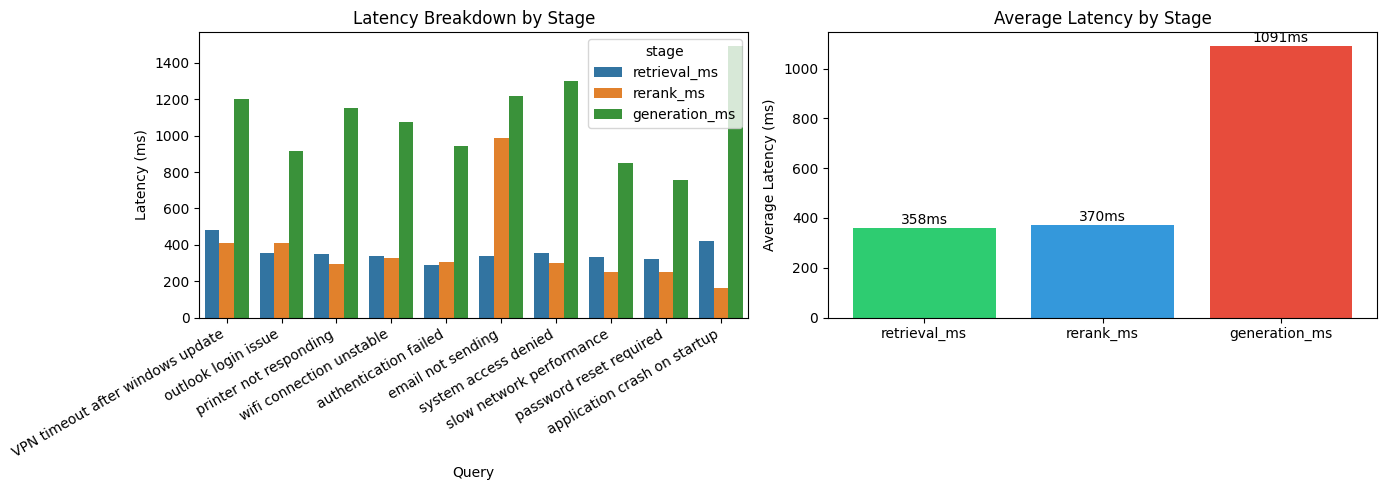

In [18]:
# ============================================================
# CELL 18 — VISUALIZE LATENCY BREAKDOWN
# ============================================================

log_step("LATENCY VISUALIZATION")

if not results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    latency_long = results_df.melt(
        id_vars=["query"],
        value_vars=["retrieval_ms", "rerank_ms", "generation_ms"],
        var_name="stage", value_name="ms"
    )
    sns.barplot(data=latency_long, x="query", y="ms", hue="stage", ax=ax)
    ax.set_title("Latency Breakdown by Stage")
    ax.set_xlabel("Query")
    ax.set_ylabel("Latency (ms)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

    ax = axes[1]
    avg_latency = results_df[["retrieval_ms", "rerank_ms", "generation_ms"]].mean()
    colors = ["#2ecc71", "#3498db", "#e74c3c"]
    bars = ax.bar(avg_latency.index, avg_latency.values, color=colors)
    ax.set_title("Average Latency by Stage")
    ax.set_ylabel("Average Latency (ms)")
    for bar, val in zip(bars, avg_latency.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                f"{val:.0f}ms", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize.")

In [19]:
# ============================================================
# CELL 19 — FINAL RAG PIPELINE REPORT
# ============================================================

log_step("FINAL RAG PIPELINE REPORT")

print("Pipeline Components:")
print(f"  FAISS Index:       {index.ntotal:,} vectors (dim={index.d})")
print(f"  BM25 Corpus:       {len(bm25_tokens):,} documents")
print(f"  Metadata:          {len(metadata_df):,} rows")
print(f"  Embedding Model:   {CONFIG['embedding_model_name']}")
print(f"  CrossEncoder:      {CONFIG['cross_encoder_model_name']}")
print(f"  LLM:               {CONFIG['llm_model_name']}")
print(f"  Groq Client:       {'Initialized' if groq_client else 'NOT AVAILABLE'}")

print(f"\nPipeline Parameters:")
print(f"  FAISS Top-K:       {CONFIG['top_k_faiss']}")
print(f"  BM25 Top-K:        {CONFIG['top_k_bm25']}")
print(f"  RRF Constant (k):  {CONFIG['rrf_k']}")
print(f"  Hybrid Top-K:      {CONFIG['hybrid_top_k']}")
print(f"  Rerank Top-K:      {CONFIG['rerank_top_k']}")
print(f"  LLM Temperature:   {CONFIG['llm_temperature']}")
print(f"  LLM Max Tokens:    {CONFIG['llm_max_tokens']}")

print(f"\nBenchmark Results:")
if not results_df.empty:
    print(f"  Avg Retrieval:     {results_df['retrieval_ms'].mean():.0f} ms")
    print(f"  Avg Rerank:        {results_df['rerank_ms'].mean():.0f} ms")
    print(f"  Avg Generation:    {results_df['generation_ms'].mean():.0f} ms")
    print(f"  Avg Total:         {results_df['total_ms'].mean():.0f} ms")
    print(f"  Avg Context:       {results_df['context_tokens'].mean():.0f} tokens")

print(f"\nExports:")
print(f"  Results:           {CONFIG['results_export_path']}")
print(f"  Benchmark:         {CONFIG['benchmark_export_path']}")
print(f"  Sample Response:   {CONFIG['sample_export_path']}")

print(f"\n{'=' * 60}")
print(f"  RAG PIPELINE EXECUTION COMPLETE")
print(f"  Ready for RAGAS evaluation")
print(f"{'=' * 60}")


  FINAL RAG PIPELINE REPORT
Pipeline Components:
  FAISS Index:       230,088 vectors (dim=384)
  BM25 Corpus:       230,088 documents
  Metadata:          230,088 rows
  Embedding Model:   sentence-transformers/all-MiniLM-L6-v2
  CrossEncoder:      cross-encoder/ms-marco-MiniLM-L-6-v2
  LLM:               llama-3.3-70b-versatile
  Groq Client:       Initialized

Pipeline Parameters:
  FAISS Top-K:       20
  BM25 Top-K:        20
  RRF Constant (k):  60
  Hybrid Top-K:      10
  Rerank Top-K:      5
  LLM Temperature:   0.1
  LLM Max Tokens:    1024

Benchmark Results:
  Avg Retrieval:     358 ms
  Avg Rerank:        370 ms
  Avg Generation:    1091 ms
  Avg Total:         1821 ms
  Avg Context:       198 tokens

Exports:
  Results:           ../evaluation/rag_pipeline_results.csv
  Benchmark:         ../evaluation/benchmarks/rag_latency.csv
  Sample Response:   ../evaluation/sample_rag_response.txt

  RAG PIPELINE EXECUTION COMPLETE
  Ready for RAGAS evaluation
